In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


## Data Collection and Processing

In [2]:
# ── FIX: Update this path to wherever your train CSV is located ──────────────
# If running on Kaggle, use: '/kaggle/input/titanic/train.csv'
# If running locally, set the correct path below.
titanic_data = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\MLPROJECTS\1. TITANIC\traintitanic.csv")


In [3]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_data.shape

(891, 12)

In [5]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Handling Missing Values

> **Note:** We do **not** drop `Cabin` here yet — we need it in the Feature Engineering section to extract `Deck`. We drop it at the end after extraction.

In [7]:
# Fill missing Age with median
titanic_data["Age"] = titanic_data["Age"].fillna(titanic_data["Age"].median())


In [8]:
# Fill missing Embarked with mode
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)


C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\781781472.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)


In [9]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

## Data Analysis

In [10]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
titanic_data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

## Data Visualisation

In [12]:
sns.set()

<Axes: xlabel='Survived', ylabel='count'>

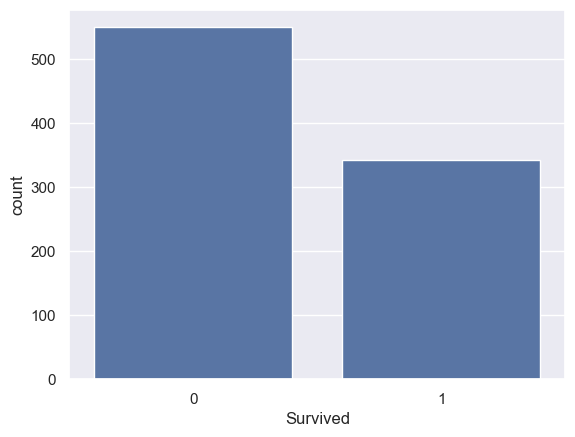

In [13]:
sns.countplot(x='Survived', data=titanic_data)

<Axes: xlabel='Sex', ylabel='count'>

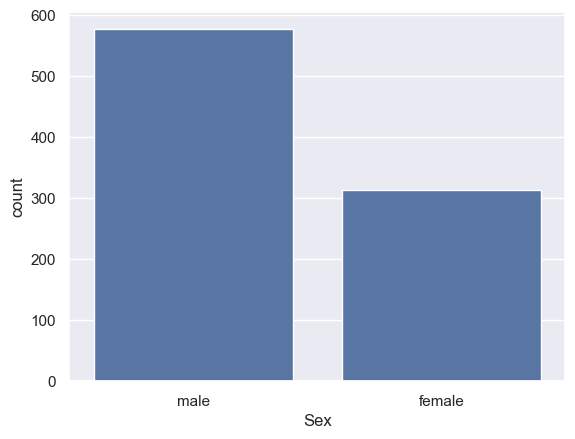

In [14]:
sns.countplot(x='Sex', data=titanic_data)

<Axes: xlabel='Sex', ylabel='count'>

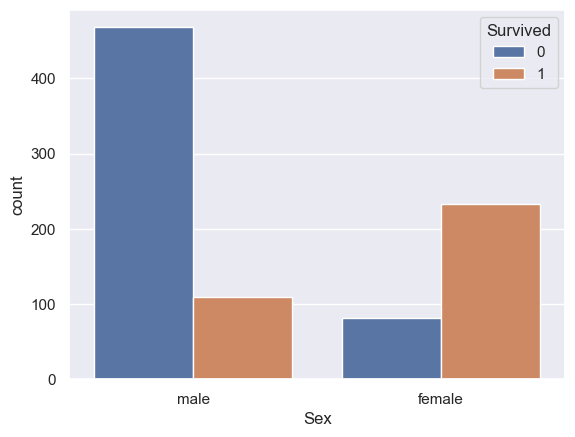

In [15]:
sns.countplot(x='Sex', hue='Survived', data=titanic_data)

<Axes: xlabel='Pclass', ylabel='count'>

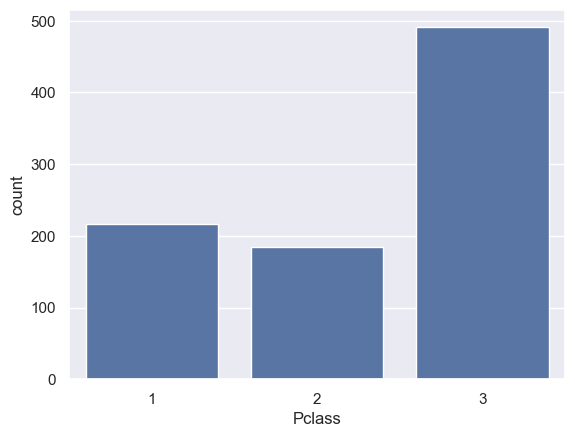

In [16]:
sns.countplot(x='Pclass', data=titanic_data)

<Axes: xlabel='Pclass', ylabel='count'>

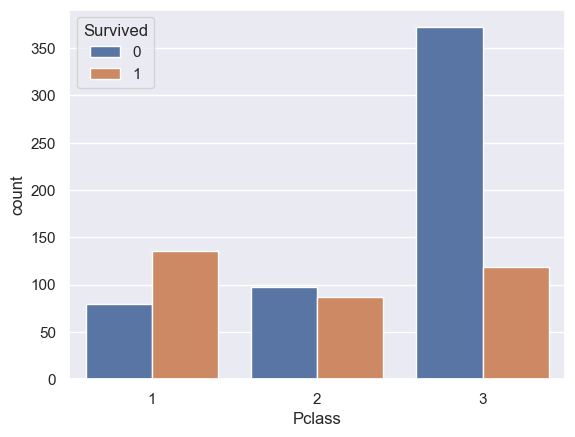

In [17]:
sns.countplot(x='Pclass', hue='Survived', data=titanic_data)

## Encoding Categorical Columns

In [18]:
titanic_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [19]:
titanic_data['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [20]:
titanic_data.replace({'Sex': {'male': 0, 'female': 1},
                      'Embarked': {'S': 0, 'C': 1, 'Q': 2}}, inplace=True)
titanic_data.head()


C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\2139688618.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic_data.replace({'Sex': {'male': 0, 'female': 1},


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0


## Feature Engineering

Here we create new, more informative columns from the existing data.  
Each new column gives the model extra signal that raw columns don't provide directly.

> **FIX:** `Cabin` is **not** dropped before this section — all deck extraction happens here cleanly, then we drop `Cabin` at the end.


In [21]:
# ── 1. EXTRACT DECK FROM CABIN ─────────────────────────────────────────────
# Cabin column is still present here (we did NOT drop it earlier — that was the bug).
# We extract the first letter (deck letter: A, B, C ... G, T) before dropping Cabin.

deck_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'T': 8, 'Unknown': 0}

titanic_data['Deck'] = titanic_data['Cabin'].str[0]
titanic_data['Deck'] = titanic_data['Deck'].fillna('Unknown')
titanic_data['Deck'] = titanic_data['Deck'].map(deck_map).fillna(0).astype(int)

# Now drop Cabin — we've extracted everything we need from it
titanic_data.drop(columns='Cabin', inplace=True)

print('Deck value counts:')
print(titanic_data['Deck'].value_counts())


Deck value counts:
Deck
0    687
3     59
2     47
4     33
5     32
1     15
6     13
7      4
8      1
Name: count, dtype: int64


In [22]:
# ── 2. FAMILY SIZE & IS ALONE ────────────────────────────────────────────────
# SibSp = siblings/spouses aboard; Parch = parents/children aboard
# +1 because we count the passenger themselves.

titanic_data['FamilySize'] = titanic_data['SibSp'] + titanic_data['Parch'] + 1
titanic_data['IsAlone'] = (titanic_data['FamilySize'] == 1).astype(int)

print('FamilySize distribution:')
print(titanic_data['FamilySize'].value_counts().sort_index())
print(f"\nTravelling alone: {titanic_data['IsAlone'].sum()} passengers")


FamilySize distribution:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Travelling alone: 537 passengers


In [23]:
# ── 3. EXTRACT TITLE FROM NAME ───────────────────────────────────────────────
# Every name looks like: 'Braund, Mr. Owen Harris'
# regex extracts the word just before a dot.

titanic_data['Title'] = titanic_data['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)
print('All titles found:')
print(titanic_data['Title'].value_counts())


All titles found:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [24]:
title_map = {
    'Mr': 1,
    'Miss': 2,
    'Mrs': 3,
    'Master': 4,
    'Dr': 5,
    'Rev': 6,
}
titanic_data['Title'] = titanic_data['Title'].map(title_map).fillna(0).astype(int)

print('Title after mapping:')
print(titanic_data['Title'].value_counts())


Title after mapping:
Title
1    517
2    182
3    125
4     40
0     14
5      7
6      6
Name: count, dtype: int64


In [25]:
# ── 4. FARE PER PERSON ───────────────────────────────────────────────────────
# Tickets were sometimes shared — divide Fare by FamilySize for individual wealth proxy.

titanic_data['FarePerPerson'] = titanic_data['Fare'] / titanic_data['FamilySize']
titanic_data['FarePerPerson'] = titanic_data['FarePerPerson'].fillna(0)

print('FarePerPerson - first 5 rows:')
print(titanic_data[['Fare', 'FamilySize', 'FarePerPerson']].head())


FarePerPerson - first 5 rows:
      Fare  FamilySize  FarePerPerson
0   7.2500           2        3.62500
1  71.2833           2       35.64165
2   7.9250           1        7.92500
3  53.1000           2       26.55000
4   8.0500           1        8.05000


In [26]:
# ── 5. AGE × PCLASS INTERACTION ──────────────────────────────────────────────
# Combines age and class into a single interaction feature.

titanic_data['AgePclass'] = titanic_data['Age'] * titanic_data['Pclass']

print('AgePclass - first 5 rows:')
print(titanic_data[['Age', 'Pclass', 'AgePclass']].head())


AgePclass - first 5 rows:
    Age  Pclass  AgePclass
0  22.0       3       66.0
1  38.0       1       38.0
2  26.0       3       78.0
3  35.0       1       35.0
4  35.0       3      105.0


In [27]:
# ── Summary: all new features ─────────────────────────────────────────────────
new_features = ['Deck', 'FamilySize', 'IsAlone', 'Title', 'FarePerPerson', 'AgePclass']
print('New feature columns added:')
titanic_data[new_features].head(10)


New feature columns added:


,Deck,FamilySize,IsAlone,Title,FarePerPerson,AgePclass
0,0,2,0,1,3.62500,66.0
1,3,2,0,3,35.64165,38.0
2,0,1,1,2,7.92500,78.0
3,3,2,0,3,26.55000,35.0
4,0,1,1,1,8.05000,105.0
5,0,1,1,1,8.45830,84.0
6,5,1,1,1,51.86250,54.0
7,0,5,0,4,4.21500,6.0
8,0,3,0,3,3.71110,81.0
9,0,2,0,3,15.03540,28.0


### Quick Visualisation — do our new features relate to survival?

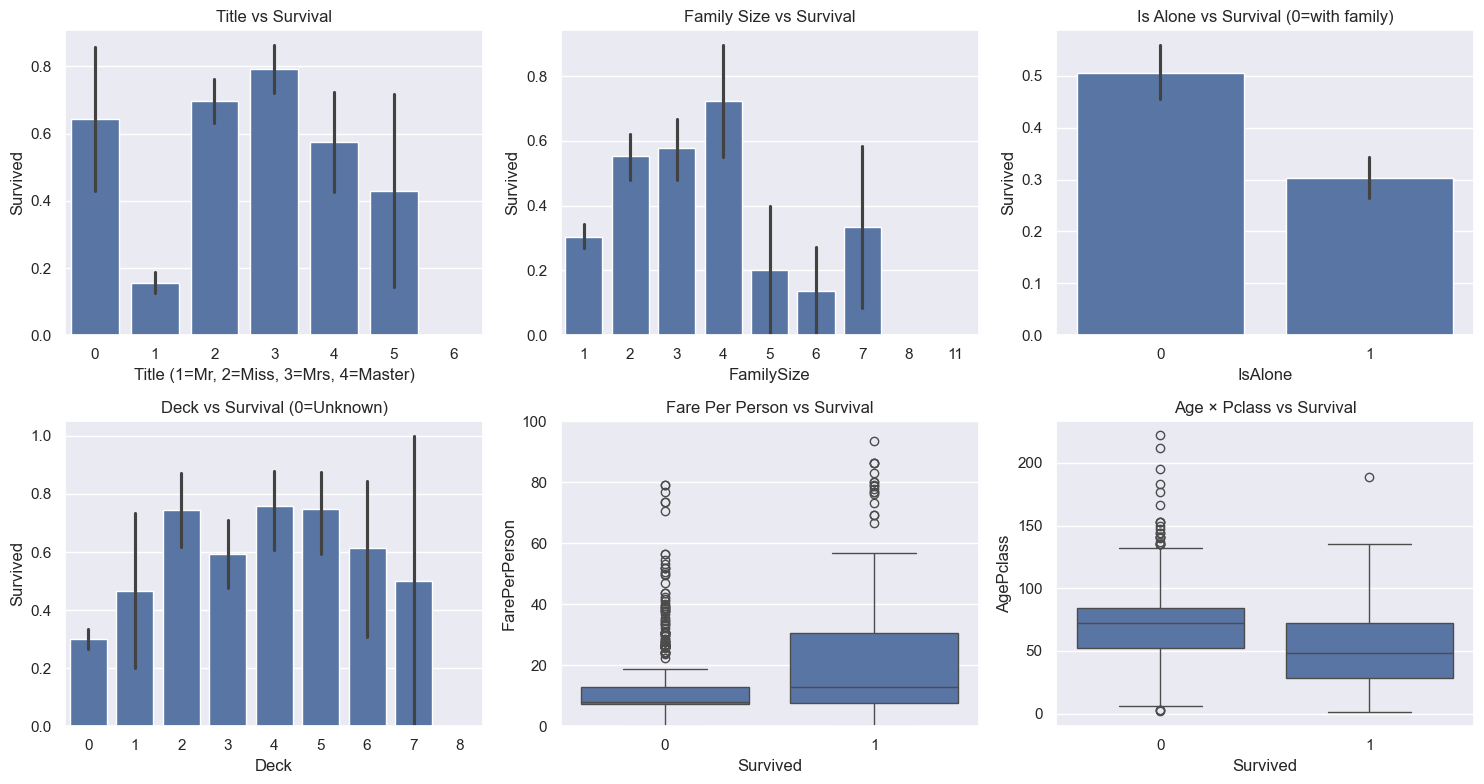

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.barplot(x='Title', y='Survived', data=titanic_data, ax=axes[0,0])
axes[0,0].set_title('Title vs Survival')
axes[0,0].set_xlabel('Title (1=Mr, 2=Miss, 3=Mrs, 4=Master)')

sns.barplot(x='FamilySize', y='Survived', data=titanic_data, ax=axes[0,1])
axes[0,1].set_title('Family Size vs Survival')

sns.barplot(x='IsAlone', y='Survived', data=titanic_data, ax=axes[0,2])
axes[0,2].set_title('Is Alone vs Survival (0=with family)')

sns.barplot(x='Deck', y='Survived', data=titanic_data, ax=axes[1,0])
axes[1,0].set_title('Deck vs Survival (0=Unknown)')

sns.boxplot(x='Survived', y='FarePerPerson', data=titanic_data, ax=axes[1,1])
axes[1,1].set_title('Fare Per Person vs Survival')
axes[1,1].set_ylim(0, 100)

sns.boxplot(x='Survived', y='AgePclass', data=titanic_data, ax=axes[1,2])
axes[1,2].set_title('Age × Pclass vs Survival')

plt.tight_layout()
plt.show()


## Separating Features and Target

In [29]:
# Drop raw columns replaced by engineered features:
#   SibSp, Parch  → FamilySize, IsAlone
#   Fare          → FarePerPerson
#   Name, Ticket  → Title extracted from Name; Ticket not useful

X = titanic_data.drop(
    columns=['PassengerId', 'Name', 'Ticket', 'Survived', 'SibSp', 'Parch', 'Fare'],
    axis=1
)
Y = titanic_data['Survived']

print('Features used for model training:')
print(list(X.columns))
print(f'\nShape: {X.shape}')


Features used for model training:
['Pclass', 'Sex', 'Age', 'Embarked', 'Deck', 'FamilySize', 'IsAlone', 'Title', 'FarePerPerson', 'AgePclass']

Shape: (891, 10)


In [30]:
print(X)

     Pclass  Sex   Age  Embarked  Deck  FamilySize  IsAlone  Title  \
0         3    0  22.0         0     0           2        0      1   
1         1    1  38.0         1     3           2        0      3   
2         3    1  26.0         0     0           1        1      2   
3         1    1  35.0         0     3           2        0      3   
4         3    0  35.0         0     0           1        1      1   
..      ...  ...   ...       ...   ...         ...      ...    ...   
886       2    0  27.0         0     0           1        1      6   
887       1    1  19.0         0     2           1        1      2   
888       3    1  28.0         0     0           4        0      2   
889       1    0  26.0         1     3           1        1      1   
890       3    0  32.0         2     0           1        1      1   

     FarePerPerson  AgePclass  
0          3.62500       66.0  
1         35.64165       38.0  
2          7.92500       78.0  
3         26.55000       35.0  

## Splitting the Data into Training and Test Sets

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2, stratify=Y
)
print(X.shape, X_train.shape, X_test.shape)


(891, 10) (712, 10) (179, 10)


## Pipelining

In [32]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])


## Model Training

In [33]:
pipeline.fit(X_train, Y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

## Model Evaluation

In [34]:
# Training accuracy
X_train_prediction = pipeline.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print('Accuracy on training data:', training_data_accuracy * 100)


Accuracy on training data: 82.7247191011236


In [35]:
# Test accuracy
X_test_prediction = pipeline.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print('Accuracy on test data:', test_data_accuracy * 100)


Accuracy on test data: 79.88826815642457


In [36]:
print(confusion_matrix(Y_test, X_test_prediction))
print('Precision:', precision_score(Y_test, X_test_prediction))
print('Recall:   ', recall_score(Y_test, X_test_prediction))


[[92 18]
 [18 51]]
Precision: 0.7391304347826086
Recall:    0.7391304347826086


In [37]:
# Cross Validation
cv_scores = cross_val_score(pipeline, X, Y, cv=5)
print('CV Scores:', cv_scores)
print('Average CV Score:', cv_scores.mean())


CV Scores: [0.80446927 0.80337079 0.79775281 0.80898876 0.85393258]
Average CV Score: 0.8137028435126483


## Kaggle Submission — Predict on test.csv

> **FIX:** All feature engineering steps are applied to `test_data` in the same order as training.  
> `deck_map` and `title_map` are already defined above — no re-definition needed.  
> `Deck` mapping now includes `'T': 8` to cover all possible cabin letters in test data, preventing NaN values that would break the pipeline.


In [38]:
# ── 1. Load Kaggle test data ─────────────────────────────────────────────────
# Update path if needed. On Kaggle: '/kaggle/input/titanic/test.csv'
test_data = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\MLPROJECTS\1. TITANIC\test.csv")

print(f'Test data shape: {test_data.shape}')  # Should be (418, 11)


Test data shape: (418, 11)


In [39]:
# ── 2. Preprocess test data (must match training exactly) ────────────────────
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)
test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)
test_data['Embarked'].fillna(test_data['Embarked'].mode()[0], inplace=True)

test_data.replace({'Sex': {'male': 0, 'female': 1},
                   'Embarked': {'S': 0, 'C': 1, 'Q': 2}}, inplace=True)


C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\190819467.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Age'].fillna(test_data['Age'].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\190819467.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [40]:
# ── 3. Apply the same feature engineering steps ──────────────────────────────

# A. Deck from Cabin (uses deck_map defined in training FE section)
test_data['Deck'] = test_data['Cabin'].str[0]
test_data['Deck'] = test_data['Deck'].fillna('Unknown')
test_data['Deck'] = test_data['Deck'].map(deck_map).fillna(0).astype(int)

# B. FamilySize & IsAlone
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1
test_data['IsAlone'] = (test_data['FamilySize'] == 1).astype(int)

# C. Title from Name (uses title_map defined in training FE section)
test_data['Title'] = test_data['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)
test_data['Title'] = test_data['Title'].map(title_map).fillna(0).astype(int)

# D. FarePerPerson
test_data['FarePerPerson'] = test_data['Fare'] / test_data['FamilySize']
test_data['FarePerPerson'] = test_data['FarePerPerson'].fillna(0)

# E. AgePclass
test_data['AgePclass'] = test_data['Age'] * test_data['Pclass']


In [41]:
# ── 4. Prepare feature matrix — drop same raw columns as in training ──────────
X_test_kaggle = test_data.drop(
    columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch', 'Fare'],
    axis=1
)

print('Test feature columns:', list(X_test_kaggle.columns))
print(f'Shape: {X_test_kaggle.shape}')  # Should be (418, 10)

# Sanity check — columns must exactly match training columns
assert list(X_test_kaggle.columns) == list(X.columns), \
    f"Column mismatch!\nExpected: {list(X.columns)}\nGot:      {list(X_test_kaggle.columns)}"
print('\n✓ Column check passed — test features match training features exactly.')


Test feature columns: ['Pclass', 'Sex', 'Age', 'Embarked', 'Deck', 'FamilySize', 'IsAlone', 'Title', 'FarePerPerson', 'AgePclass']
Shape: (418, 10)

✓ Column check passed — test features match training features exactly.


In [42]:
# ── 5. Predict & save submission ─────────────────────────────────────────────
final_predictions = pipeline.predict(X_test_kaggle)

submission_fe = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': final_predictions
})

print(f'Submission shape: {submission_fe.shape}')  # Must be (418, 2)
print(submission_fe.head(10))

submission_fe.to_csv('submission_feature_engineered.csv', index=False)
print("\n✓ Saved: submission_feature_engineered.csv")


Submission shape: (418, 2)
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

✓ Saved: submission_feature_engineered.csv


In [43]:
import pickle
pickle.dump(pipeline, open("model.pkl", "wb"))